# Microgravity Accelerometer Analysis

Cleaned/smoothed accelerometer trace from `data/`: 2-D time series, 3-D trajectory, and time-averaged net-acceleration convergence.

In [ ]:
import sys; sys.path.insert(0, '.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import matplotlib.cm as cm
from scipy.signal import savgol_filter

from mltoolkit import detect_outliers
from mltoolkit.viz.defaults import PLOT_DEFAULTS

# Set Arial font globally
font_path = '/usr/share/fonts/truetype/msttcorefonts/Arial.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

In [ ]:
# --- Data loading & cleaning ---
raw = pd.read_csv('data/accelerometer.txt', sep='\t')
print(f"Raw shape: {raw.shape}")

# Rename Chinese columns to English, keep acceleration + time
col_map = {
    '时间': 'Time',
    '加速度X(g)': 'Acc_X',
    '加速度Y(g)': 'Acc_Y',
    '加速度Z(g)': 'Acc_Z',
}
df = raw.rename(columns=col_map)[list(col_map.values())].copy()

# Parse timestamps and compute elapsed time
df['Time'] = pd.to_datetime(df['Time'])
t0 = df['Time'].iloc[0]
df['elapsed_s'] = (df['Time'] - t0).dt.total_seconds()
print(f"Time range: {df['elapsed_s'].min():.1f} – {df['elapsed_s'].max():.1f} s "
      f"({df['elapsed_s'].max()/60:.1f} min)")

# Outlier removal (IQR on all 3 axes)
info, removed, df_clean = detect_outliers(df, ['Acc_X', 'Acc_Y', 'Acc_Z'], method='iqr')
print(f"Outliers removed: {info['n_outliers']} / {len(df)} rows")
for col_name, col_info in info['per_column'].items():
    stats = col_info['stats']
    print(f"  {col_name}: bounds [{stats['lower_bound']:.3f}, {stats['upper_bound']:.3f}]")

# Slice to 10 min offset, sort by time to fix backward jumps
df_clean = df_clean[df_clean['elapsed_s'] >= 600].copy()
df_clean = df_clean.sort_values('elapsed_s').reset_index(drop=True)
df_clean['t'] = df_clean['elapsed_s'] - 600.0

# Savitzky-Golay smoothing
WINDOW_LENGTH = 15  # ~3 seconds at 5.3 Hz (must be odd)
POLY_ORDER = 3
for col in ['Acc_X', 'Acc_Y', 'Acc_Z']:
    df_clean[col] = savgol_filter(df_clean[col], WINDOW_LENGTH, POLY_ORDER)
print(f"Savitzky-Golay smoothing: window={WINDOW_LENGTH}, poly_order={POLY_ORDER}")

print(f"\nAfter cleaning & slicing: {len(df_clean)} rows, "
      f"t = 0 – {df_clean['t'].max():.1f} s ({df_clean['t'].max()/60:.1f} min)")

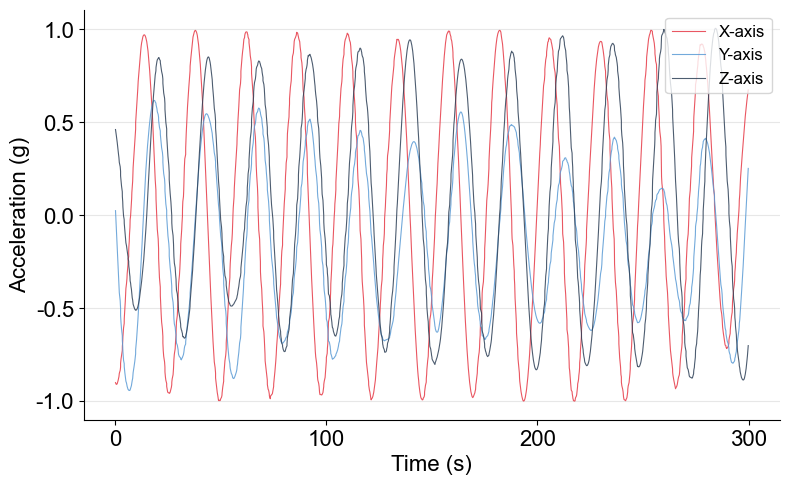

In [3]:
import os
os.makedirs('plots/microgravity', exist_ok=True)

# Shared figure-sizing constants
# 2D = 8"x5" canvas, 3D = 4"x5" canvas → both render at 0.75x in PPT, matching text/line scale.
# When placed: 2D at 6" (2 slots), 3D at 3" (1 slot) on a 12" slide.
FIGSIZE_2D = (8, 5)
MARGINS_2D = dict(left=0.10, right=0.97, top=0.95, bottom=0.13)

# --- Plot 1: 2D Time Series (0–300 s window) ---
window = df_clean[df_clean['t'] <= 300].copy()

fig, ax = plt.subplots(figsize=FIGSIZE_2D)

colors = {'Acc_X': '#E63946', 'Acc_Y': '#5B9BD5', 'Acc_Z': '#2E4057'}
labels = {'Acc_X': 'X-axis', 'Acc_Y': 'Y-axis', 'Acc_Z': 'Z-axis'}

for col in ['Acc_X', 'Acc_Y', 'Acc_Z']:
    ax.plot(window['t'], window[col], color=colors[col], label=labels[col],
            linewidth=0.8, alpha=0.85)

ax.set_xlabel('Time (s)', fontsize=PLOT_DEFAULTS['title_fontsize'])
ax.set_ylabel('Acceleration (g)', fontsize=PLOT_DEFAULTS['title_fontsize'])
ax.set_xticks([0, 100, 200, 300])
ax.set_yticks([1.0, 0.5, 0.0, -0.5, -1.0])
ax.set_yticklabels(['1.0', '0.5', '0.0', '-0.5', '-1.0'])
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=PLOT_DEFAULTS['tick_fontsize'], loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.subplots_adjust(**MARGINS_2D)
fig.savefig('plots/microgravity/microgravity_accel_timeseries.svg', format='svg')
plt.show()

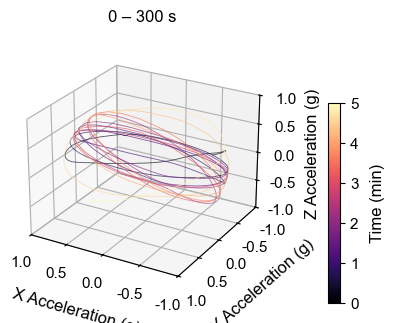

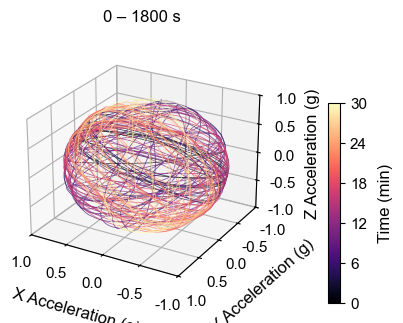

In [4]:
FIGSIZE_3D = (4, 5)

# Manual axes positioning (figure-relative coords) — guarantees Z-label/cb separation
AX3D_POS = [0.02, 0.08, 0.65, 0.88]   # 3D axes
CAX_POS  = [0.81, 0.25, 0.030, 0.40]  # colorbar strip
ZLABEL_POS = (0.77, 0.55)             # pushed upward to clear longer Y axis label

# --- Plot 2: 3D Trajectory — one SVG per duration ---
durations = [300, 1800]
titles = ['0 – 300 s', '0 – 1800 s']
suffixes = ['300s', '1800s']
# Tick positions in seconds (data domain) and labels in minutes
cbar_ticks_list = [
    [0, 60, 120, 180, 240, 300],
    [0, 360, 720, 1080, 1440, 1800],
]
cbar_tick_labels_list = [
    [0, 1, 2, 3, 4, 5],
    [0, 6, 12, 18, 24, 30],
]
axis_ticks = [-1.0, -0.5, 0.0, 0.5, 1.0]
tick_labels = ['-1.0', '-0.5', '0.0', '0.5', '1.0']

TICK_FS = 11   # shared between 3D axis ticks and cbar ticks

for dur, title, suffix, cbar_ticks, cbar_tick_labels in zip(
        durations, titles, suffixes, cbar_ticks_list, cbar_tick_labels_list):
    fig = plt.figure(figsize=FIGSIZE_3D)
    ax = fig.add_axes(AX3D_POS, projection='3d')
    cax = fig.add_axes(CAX_POS)

    sub = df_clean[df_clean['t'] <= dur]
    x = sub['Acc_X'].values
    y = sub['Acc_Y'].values
    z = sub['Acc_Z'].values
    t = sub['t'].values

    points = np.array([x, y, z]).T.reshape(-1, 1, 3)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = plt.Normalize(0, dur)
    lc = Line3DCollection(segments, cmap='magma', norm=norm, linewidths=0.6, alpha=0.7)
    lc.set_array(t[:-1])
    ax.add_collection3d(lc)

    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])
    ax.set_xticks(axis_ticks, tick_labels, fontsize=TICK_FS)
    ax.set_yticks(axis_ticks, tick_labels, fontsize=TICK_FS)
    ax.set_zticks(axis_ticks, tick_labels, fontsize=TICK_FS)

    ax.set_xlabel('X Acceleration (g)', fontsize=12, labelpad=8)
    ax.set_ylabel('Y Acceleration (g)', fontsize=12, labelpad=8)
    ax.set_zlabel('')   # disable matplotlib's auto Z label (collides with cb)
    ax.set_title(title, fontsize=12, pad=12)
    ax.view_init(elev=25, azim=120)

    # Manual Z label in figure-relative coords
    fig.text(*ZLABEL_POS, 'Z Acceleration (g)', rotation=90, fontsize=12, va='center', ha='center')

    mappable = cm.ScalarMappable(norm=norm, cmap='magma')
    mappable.set_array(t)
    cb = fig.colorbar(mappable, cax=cax, ticks=cbar_ticks)
    cb.ax.set_yticklabels([str(v) for v in cbar_tick_labels])
    cb.set_label('Time (min)', fontsize=12, labelpad=8)
    cb.ax.tick_params(labelsize=TICK_FS)

    fig.savefig(f'plots/microgravity/microgravity_accel_3d_trajectory_{suffix}.svg', format='svg')
    plt.show()

Time-averaged acceleration per axis:
  <a_x> = -0.007835 g
  <a_y> = -0.026265 g
  <a_z> = 0.012953 g
  sqrt(<a_x>² + <a_y>² + <a_z>²) = 0.030316 g
  = 30.316 mg  (milli-g)


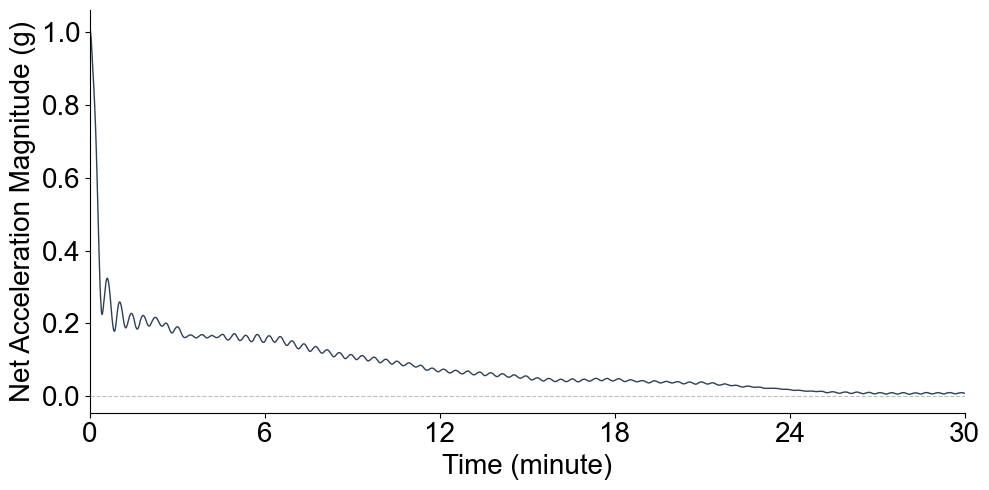

In [ ]:
# Time-averaged acceleration magnitude
# sqrt( <a_x>_t^2 + <a_y>_t^2 + <a_z>_t^2 )
# 2-axis clinostat randomizes orientation, so the time-averaged gravity vector cancels → residual ≈ 0.

cum_mean_x = df_clean['Acc_X'].expanding().mean()
cum_mean_y = df_clean['Acc_Y'].expanding().mean()
cum_mean_z = df_clean['Acc_Z'].expanding().mean()
cum_mag = np.sqrt(cum_mean_x**2 + cum_mean_y**2 + cum_mean_z**2)

# Final value
mean_x = df_clean['Acc_X'].mean()
mean_y = df_clean['Acc_Y'].mean()
mean_z = df_clean['Acc_Z'].mean()
final_mag = np.sqrt(mean_x**2 + mean_y**2 + mean_z**2)

print(f"Time-averaged acceleration per axis:")
print(f"  <a_x> = {mean_x:.6f} g")
print(f"  <a_y> = {mean_y:.6f} g")
print(f"  <a_z> = {mean_z:.6f} g")
print(f"  sqrt(<a_x>² + <a_y>² + <a_z>²) = {final_mag:.6f} g")
print(f"  = {final_mag * 1000:.3f} mg  (milli-g)")

# Plot convergence
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_clean['t'], cum_mag, color='#2E4057', linewidth=1.0)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlim(0, 1800)
ax.set_xticks([0, 360, 720, 1080, 1440, 1800])
ax.set_xticklabels(['0', '6', '12', '18', '24', '30'])
ax.set_xlabel('Time (minute)', fontsize=20)
ax.set_ylabel('Net Acceleration Magnitude (g)', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig('plots/microgravity/microgravity_net_accel_magnitude.svg', format='svg')
plt.show()